# Full Pipeline (v2) — AF(d), PSD/β, ApEn, SampEn — 34 Years

**Input:** `AF_Counts_AllYears.xlsx` — one sheet per year (1988–2021), columns `distance` and `AF`, produced directly by the automated ring-intersection notebook (no repeated-row counting needed here — counts are already computed).

**Workflow**
1. Load all year sheets, handle any flagged/missing values
2. Normalize d (d/R) and AF (AF/total) — Section 3.3
3. **Figure 6a** — AF(d) vs distance, all years, colored by year
4. PSD via FFT per year — Section 3.6
5. **Figure 6b** — PSD vs wave number, log–log, colored by year
6. Fit log–log slope → β per year
7. **Figure 7b** — β by year (bar chart)
8. ApEn and SampEn per year (m=2, r=0.15×std) — Section 3.5
9. **Figure 7a** — ApEn and SampEn by year (bar chart)
10. Save combined results

In [1]:
import numpy as np                    # arrays, FFT, linear algebra
import pandas as pd                   # reading Excel sheets, building tables
import matplotlib.pyplot as plt       # plotting all four figures
import matplotlib.cm as cm            # colormap for coloring lines by year
import matplotlib.colors as mcolors   # normalizing year values onto the colormap
from scipy.stats import linregress    # least-squares fit for the PSD log-log slope (beta)

---
## Step 1 — Load AF counts for every year

In [2]:
FILE_PATH = r"G:\Cahnnel Complexity Ganges\AF_Counts_AllYears.xlsx"   # output from the automated counting notebook

xls = pd.ExcelFile(FILE_PATH)
sheet_names = xls.sheet_names                  # sheet names = years, as strings
years = sorted(int(y) for y in sheet_names)    # numeric, sorted, for coloring and x-axis ordering
print(f"Found {len(years)} years:", years)

Found 34 years: [1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]


---
## Step 2 — Build distance/AF arrays per year, handle flagged (NaN) rings

Every sheet already has one row per ring (41 rings), so the grid is already uniform — no gap-filling needed here. Any `AF = NaN` (a flagged ring from the automated intersection step) is set to 0 with a printed warning, since it means that ring's crossing count couldn't be resolved automatically and should be spot-checked separately in QGIS.

In [3]:
d_data = {}    # year -> distance array (meters)
af_data = {}   # year -> raw AF count array

for year in years:
    df = pd.read_excel(FILE_PATH, sheet_name=str(year))
    df = df.sort_values("distance").reset_index(drop=True)     # ensure ascending distance order

    n_nan = df["AF"].isna().sum()
    if n_nan > 0:
        print(f"Year {year}: {n_nan} flagged ring(s) set to AF=0 -- verify manually if this matters")
    df["AF"] = df["AF"].fillna(0)                               # treat unresolved rings as 0 crossings

    d_data[year] = df["distance"].to_numpy(dtype=float)
    af_data[year] = df["AF"].to_numpy(dtype=float)

---
## Step 3 — Normalize d and AF(d)  (Section 3.3)

In [4]:
def normalize_af(distances, af_vector):
    R = distances.max()             # max radial distance this year -> normalizes d to 0-1
    total = af_vector.sum()         # total crossings this year -> normalizes AF to sum-to-1
    if total == 0:
        raise ValueError("Total AF is zero -- check this year's data before continuing.")
    d_norm = distances / R
    af_norm = af_vector / total
    return d_norm, af_norm

d_norm_data = {}
af_norm_data = {}

for year in years:
    d_norm, af_norm = normalize_af(d_data[year], af_data[year])
    d_norm_data[year] = d_norm
    af_norm_data[year] = af_norm

---
## Step 4 — Set up a shared color scale for year (used by Figures 6a and 6b)

With 34 years, a normal legend would be unreadable, so each line is colored by year on a continuous colormap, with a colorbar instead of a legend list.

In [5]:
cmap = cm.get_cmap("viridis")                                  # perceptually uniform colormap
norm = mcolors.Normalize(vmin=min(years), vmax=max(years))      # maps year values -> [0,1] for the colormap

def year_color(year):
    return cmap(norm(year))

C:\Users\rbe\AppData\Local\Temp\ipykernel_13764\995256581.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis")                                  # perceptually uniform colormap


---
## Figure 6a — AF(d) vs distance from mouth, all years, colored by year

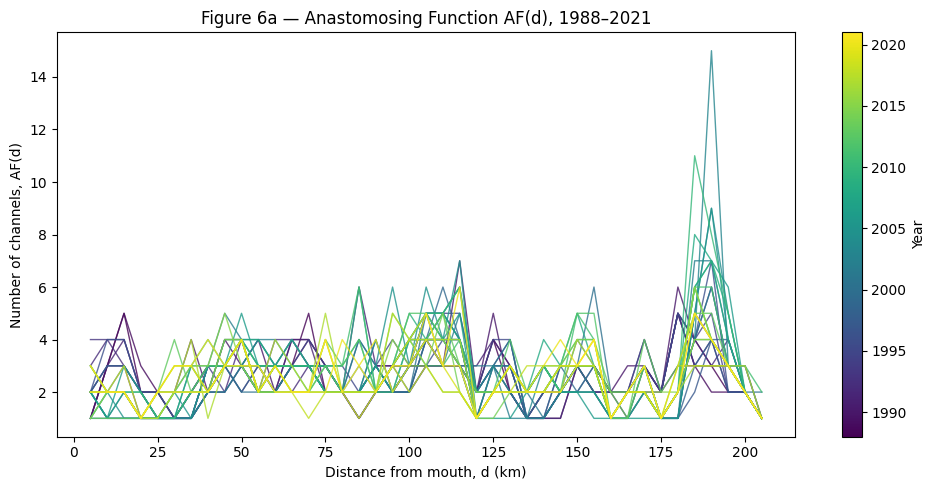

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

for year in years:
    d_km = d_data[year] / 1000.0                 # meters -> km for the x-axis
    ax.plot(d_km, af_data[year], color=year_color(year), linewidth=1, alpha=0.8)

sm = cm.ScalarMappable(cmap=cmap, norm=norm)      # dummy mappable, needed to draw the colorbar
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Year")

ax.set_xlabel("Distance from mouth, d (km)")
ax.set_ylabel("Number of channels, AF(d)")
ax.set_title("Figure 6a — Anastomosing Function AF(d), 1988–2021")
plt.tight_layout()
plt.show()

---
## Step 5 — Power Spectral Density (PSD) function  (Section 3.6, Eq. 14)

In [7]:
def compute_psd(af_signal, delta_d_km):
    """
    af_signal  : normalized AF(d), evenly spaced
    delta_d_km : spacing between samples in km (5 km here)
    Returns wave number k (cycles/km) and PSD(k), positive frequencies only.
    """
    N = len(af_signal)
    fft_vals = np.fft.rfft(af_signal)             # FFT of a real-valued signal -> non-negative freqs only
    psd = np.abs(fft_vals) ** 2 / (2 * np.pi)      # |FFT|^2, scaled per Eq. 14
    k = np.fft.rfftfreq(N, d=delta_d_km)           # wave number in cycles/km for each FFT bin

    k = k[1:]      # drop k=0 (the mean/DC term -- not a fluctuation, and log(0) is undefined)
    psd = psd[1:]
    return k, psd

---
## Step 6 — Compute PSD for every year

In [8]:
DELTA_D_KM = 5.0    # ring spacing in km

psd_data = {}   # year -> (k array, PSD array)

for year in years:
    k_vals, psd_vals = compute_psd(af_norm_data[year], DELTA_D_KM)
    psd_data[year] = (k_vals, psd_vals)

---
## Figure 6b — PSD vs wave number, log–log, all years, colored by year

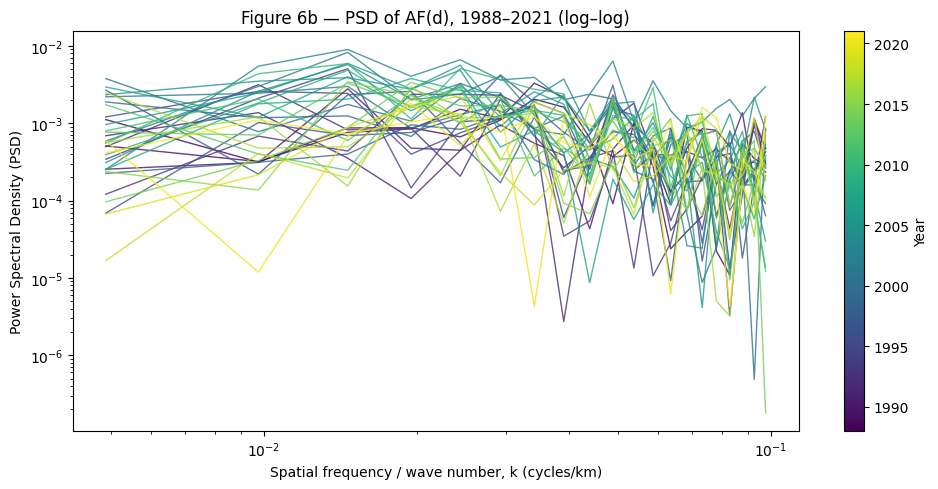

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

for year in years:
    k_vals, psd_vals = psd_data[year]
    ax.plot(k_vals, psd_vals, color=year_color(year), linewidth=1, alpha=0.8)

ax.set_xscale('log')
ax.set_yscale('log')

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Year")

ax.set_xlabel("Spatial frequency / wave number, k (cycles/km)")
ax.set_ylabel("Power Spectral Density (PSD)")
ax.set_title("Figure 6b — PSD of AF(d), 1988–2021 (log–log)")
plt.tight_layout()
plt.show()

---
## Step 7 — Fit log–log slope → β per year  (Eq. 15)

In [10]:
beta_results = []

for year in years:
    k_vals, psd_vals = psd_data[year]
    log_k = np.log10(k_vals)
    log_psd = np.log10(psd_vals)

    slope, intercept, r_value, p_value, std_err = linregress(log_k, log_psd)   # least-squares line fit
    beta = abs(slope)                                                          # beta = |slope|

    beta_results.append({"Year": year, "beta": beta, "R2": r_value**2, "p_value": p_value})

beta_df = pd.DataFrame(beta_results)
beta_df

,Year,beta,R2,p_value
0,1988,0.676701,0.172182,0.068874
1,1989,0.739998,0.189231,0.055256
2,1990,0.074074,0.004350,0.782339
3,1991,0.405785,0.118931,0.136462
4,1992,0.380006,0.046999,0.358573
5,1993,0.549161,0.083559,0.216420
6,1994,0.986524,0.180454,0.061903
7,1995,0.766062,0.325351,0.008636
8,1996,0.178539,0.012098,0.644349
9,1997,0.830275,0.254430,0.023330


---
## Figure 7b — β (PSD slope) by year

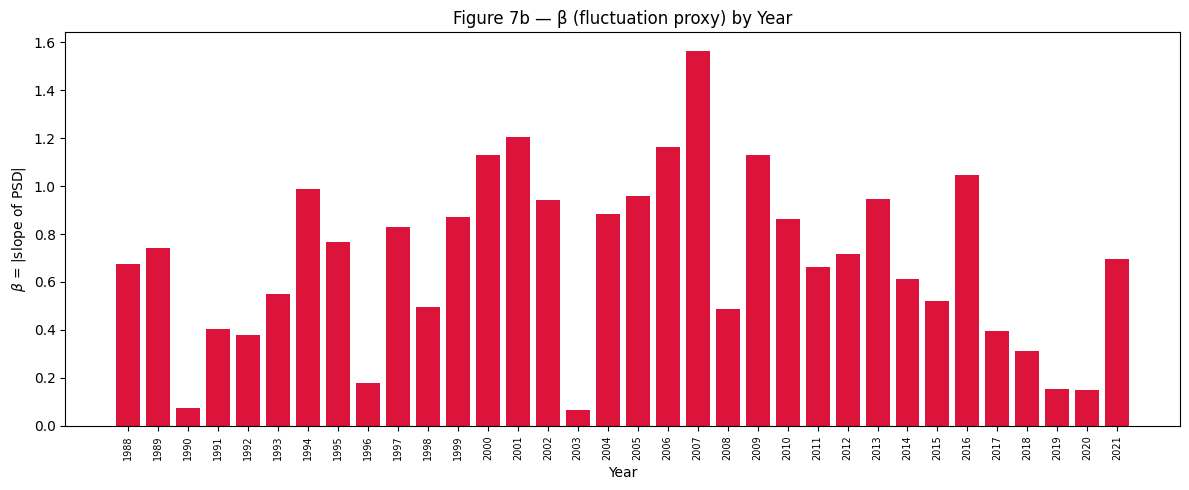

In [11]:
plt.figure(figsize=(12, 5))
plt.bar(beta_df["Year"].astype(str), beta_df["beta"], color="crimson")
plt.xlabel("Year")
plt.ylabel(r"$\beta$ = |slope of PSD|")
plt.title("Figure 7b — β (fluctuation proxy) by Year")
plt.xticks(rotation=90, fontsize=7)     # rotate + shrink labels since there are 34 of them
plt.tight_layout()
plt.show()

---
## Step 8 — ApEn and SampEn functions  (Section 3.5)

In [12]:
def form_vectors(series, length):
    N = len(series)
    return np.array([series[i:i + length] for i in range(N - length + 1)])   # sliding windows

def distance_matrix(vecs):
    n_vec = len(vecs)
    D = np.zeros((n_vec, n_vec))
    for i in range(n_vec):
        for j in range(n_vec):
            D[i, j] = np.max(np.abs(vecs[i] - vecs[j]))    # Chebyshev distance
    return D

def _phi(series, m, r):
    vecs = form_vectors(series, m)
    D = distance_matrix(vecs)
    C = np.sum(D <= r, axis=1) / len(vecs)         # fraction of templates within tolerance r (incl. self)
    return np.mean(np.log(C))

def approximate_entropy(series, m, r):
    series = np.asarray(series, dtype=float)
    return _phi(series, m, r) - _phi(series, m + 1, r)

def sample_entropy(series, m, r):
    series = np.asarray(series, dtype=float)

    def _count_matches(mlen):
        vecs = form_vectors(series, mlen)
        n_vec = len(vecs)
        count = 0
        for i in range(n_vec):
            for j in range(i + 1, n_vec):            # i<j only -> excludes self, no double count
                d = np.max(np.abs(vecs[i] - vecs[j]))
                if d <= r:
                    count += 1
        return count

    B = _count_matches(m)
    A = _count_matches(m + 1)

    if B == 0 or A == 0:
        return np.nan
    return -np.log(A / B)

---
## Step 9 — Compute ApEn and SampEn per year (m=2, r=0.15×std)

In [13]:
m_val = 2
entropy_results = []

for year in years:
    af_norm = af_norm_data[year]
    r_year = 0.15 * np.std(af_norm)

    apen_val = approximate_entropy(af_norm, m_val, r_year)
    sampen_val = sample_entropy(af_norm, m_val, r_year)

    entropy_results.append({"Year": year, "N": len(af_norm), "r": r_year,
                             "ApEn": apen_val, "SampEn": sampen_val})

entropy_df = pd.DataFrame(entropy_results)
entropy_df

,Year,N,r,ApEn,SampEn
0,1988,41,0.001507,0.653742,0.963438
1,1989,41,0.001528,0.663365,1.292768
2,1990,41,0.001520,0.610322,1.352393
3,1991,41,0.001439,0.626358,1.386294
4,1992,41,0.001586,0.711012,1.318241
5,1993,41,0.001515,0.700470,1.481605
6,1994,41,0.001577,0.760162,1.330414
7,1995,41,0.001593,0.505607,1.178655
8,1996,41,0.001739,0.722658,1.427116
9,1997,41,0.001642,0.793499,1.455287


---
## Figure 7a — ApEn and SampEn by year (dual-axis bar chart)

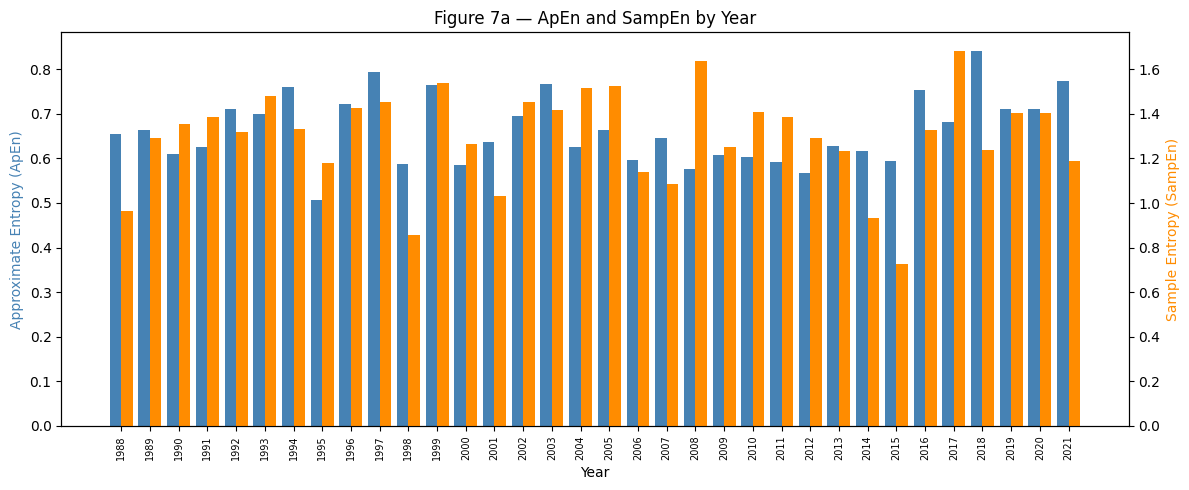

In [14]:
fig, ax1 = plt.subplots(figsize=(12, 5))

x_pos = np.arange(len(entropy_df))
width = 0.4

ax1.bar(x_pos - width/2, entropy_df["ApEn"], width=width, color="steelblue", label="ApEn")
ax1.set_ylabel("Approximate Entropy (ApEn)", color="steelblue")
ax1.set_xticks(x_pos)
ax1.set_xticklabels(entropy_df["Year"].astype(str), rotation=90, fontsize=7)

ax2 = ax1.twinx()
ax2.bar(x_pos + width/2, entropy_df["SampEn"], width=width, color="darkorange", label="SampEn")
ax2.set_ylabel("Sample Entropy (SampEn)", color="darkorange")

ax1.set_xlabel("Year")
ax1.set_title("Figure 7a — ApEn and SampEn by Year")
fig.tight_layout()
plt.show()

---
## Step 10 — Combine and save all results

In [15]:
final_df = entropy_df.merge(beta_df[["Year", "beta", "R2"]], on="Year")
print(final_df)

OUTPUT_PATH = r"G:\Cahnnel Complexity Ganges\AF_Full_Results_34Years.xlsx"
final_df.to_excel(OUTPUT_PATH, index=False)
print(f"\nSaved combined results to: {OUTPUT_PATH}")

    Year   N         r      ApEn    SampEn      beta        R2
0   1988  41  0.001507  0.653742  0.963438  0.676701  0.172182
1   1989  41  0.001528  0.663365  1.292768  0.739998  0.189231
2   1990  41  0.001520  0.610322  1.352393  0.074074  0.004350
3   1991  41  0.001439  0.626358  1.386294  0.405785  0.118931
4   1992  41  0.001586  0.711012  1.318241  0.380006  0.046999
5   1993  41  0.001515  0.700470  1.481605  0.549161  0.083559
6   1994  41  0.001577  0.760162  1.330414  0.986524  0.180454
7   1995  41  0.001593  0.505607  1.178655  0.766062  0.325351
8   1996  41  0.001739  0.722658  1.427116  0.178539  0.012098
9   1997  41  0.001642  0.793499  1.455287  0.830275  0.254430
10  1998  41  0.001419  0.587839  0.857450  0.495493  0.096671
11  1999  41  0.001660  0.763592  1.540445  0.872623  0.431950
12  2000  41  0.001997  0.585384  1.263692  1.130142  0.232879
13  2001  41  0.001722  0.637683  1.033015  1.203181  0.407756
14  2002  41  0.002210  0.694709  1.452252  0.940215  0

# Cell — Load discharge data and compute yearly Qmax, Qmwet, Qmdry

In [16]:
# ---- Load Hardinge Bridge daily discharge data ----
Q_PATH = r"G:\Cahnnel Complexity Ganges\HB_Q_1934-2025.xlsx"

q_df = pd.read_excel(Q_PATH)                      # columns: date, Q
q_df["date"] = pd.to_datetime(q_df["date"])        # ensure proper datetime type
q_df["year"] = q_df["date"].dt.year                # extract calendar year
q_df["month"] = q_df["date"].dt.month              # extract month (1-12)

# ---- Define wet (monsoon) and dry (non-monsoon) season months ----
# Ganges monsoon season is roughly June-October; adjust here if your definition differs
WET_MONTHS = [6, 7, 8, 9, 10]
DRY_MONTHS = [11, 12, 1, 2, 3, 4, 5]

# ---- Yearly maximum discharge (Qmax) ----
q_max = q_df.groupby("year")["Q"].max().rename("Qmax")

# ---- Mean wet-season discharge (Qmwet) ----
q_wet = q_df[q_df["month"].isin(WET_MONTHS)].groupby("year")["Q"].mean().rename("Qmwet")

# ---- Mean dry-season discharge (Qmdry) ----
q_dry = q_df[q_df["month"].isin(DRY_MONTHS)].groupby("year")["Q"].mean().rename("Qmdry")

# ---- Combine into one discharge summary table ----
discharge_df = pd.concat([q_max, q_wet, q_dry], axis=1).reset_index()
discharge_df = discharge_df.rename(columns={"year": "Year"})
discharge_df.head()

,Year,Qmax,Qmwet,Qmdry
0,1934,46600.0,23720.065359,3427.868852
1,1935,44000.0,19220.588235,2698.773585
2,1936,45300.0,24479.346405,2822.253521
3,1937,39400.0,19663.921569,3026.462264
4,1938,47800.0,24907.124183,2844.481132


# Cell — Merge discharge with your entropy/β results

In [17]:
# ---- Merge discharge (Qmax, Qmwet, Qmdry) with ApEn/SampEn/beta results by Year ----
merged_df = final_df.merge(discharge_df, on="Year", how="inner")   # keep only years present in both tables

print(f"Years matched: {len(merged_df)} (out of {len(final_df)} AF years, {len(discharge_df)} discharge years)")
merged_df

Years matched: 34 (out of 34 AF years, 92 discharge years)


,Year,N,r,ApEn,SampEn,beta,R2,Qmax,Qmwet,Qmdry
0,1988,41,0.001507,0.653742,0.963438,0.676701,0.172182,71800.000000,25410.915033,1653.798122
1,1989,41,0.001528,0.663365,1.292768,0.739998,0.189231,31500.000000,18483.594771,1530.070755
2,1990,41,0.001520,0.610322,1.352393,0.074074,0.004350,51000.000000,26151.045752,1792.183962
3,1991,41,0.001439,0.626358,1.386294,0.405785,0.118931,55600.000000,18961.045752,1533.226415
4,1992,41,0.001586,0.711012,1.318241,0.380006,0.046999,41800.000000,13155.490196,1488.201878
5,1993,41,0.001515,0.700470,1.481605,0.549161,0.083559,44700.000000,18161.045752,1630.339623
6,1994,41,0.001577,0.760162,1.330414,0.986524,0.180454,45900.000000,20312.209150,1492.264151
7,1995,41,0.001593,0.505607,1.178655,0.766062,0.325351,49100.000000,23933.071895,1968.396226
8,1996,41,0.001739,0.722658,1.427116,0.178539,0.012098,54061.500000,23874.975752,2085.529484
9,1997,41,0.001642,0.793499,1.455287,0.830275,0.254430,42829.120000,19226.444771,2183.710708


# Cell — Helper function: scatter + regression line + R²/p-value annotation

In [18]:
def plot_correlation(ax, x, y, xlabel, ylabel):
    """Scatter plot with fitted regression line, R^2 and p-value annotated -- matches paper's Fig 8/9/10 style."""
    slope, intercept, r_value, p_value, std_err = linregress(x, y)   # least-squares fit

    ax.scatter(x, y, facecolors="none", edgecolors="blue")            # open circles, matching paper style
    x_line = np.linspace(x.min(), x.max(), 50)
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, "k--", linewidth=1)                       # dashed best-fit line

    r2 = r_value ** 2
    ax.text(0.97, 0.95, f"R² = {r2:.2f}\nR = {r_value:.2f}\np-value \u2264 {p_value:.3f}",
            transform=ax.transAxes, ha="right", va="top", fontsize=9)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

# Cell — Figure 8: ApEn vs Qmax, Qmwet, Qmdry

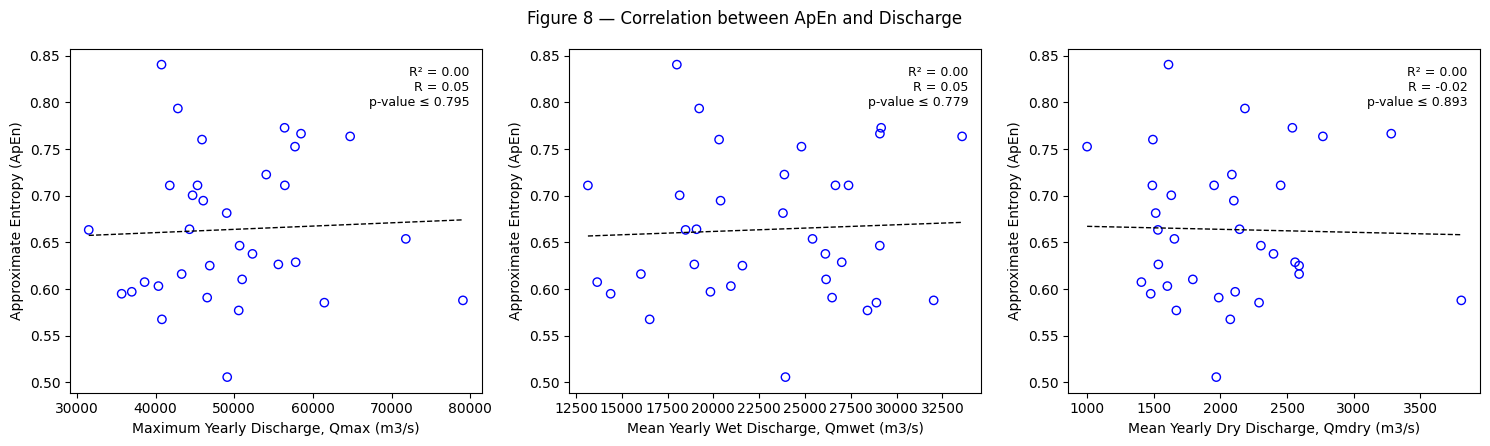

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

plot_correlation(axes[0], merged_df["Qmax"], merged_df["ApEn"],
                  "Maximum Yearly Discharge, Qmax (m3/s)", "Approximate Entropy (ApEn)")
plot_correlation(axes[1], merged_df["Qmwet"], merged_df["ApEn"],
                  "Mean Yearly Wet Discharge, Qmwet (m3/s)", "Approximate Entropy (ApEn)")
plot_correlation(axes[2], merged_df["Qmdry"], merged_df["ApEn"],
                  "Mean Yearly Dry Discharge, Qmdry (m3/s)", "Approximate Entropy (ApEn)")

fig.suptitle("Figure 8 \u2014 Correlation between ApEn and Discharge")
plt.tight_layout()
plt.show()

# Cell — Figure 9: SampEn vs Qmax, Qmwet, Qmdry

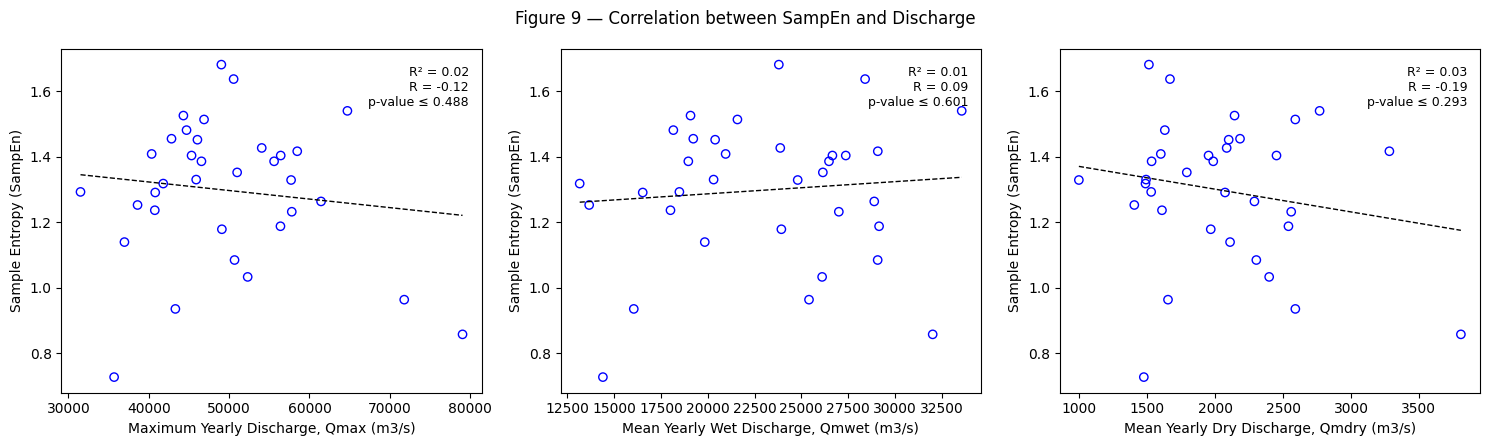

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

plot_correlation(axes[0], merged_df["Qmax"], merged_df["SampEn"],
                  "Maximum Yearly Discharge, Qmax (m3/s)", "Sample Entropy (SampEn)")
plot_correlation(axes[1], merged_df["Qmwet"], merged_df["SampEn"],
                  "Mean Yearly Wet Discharge, Qmwet (m3/s)", "Sample Entropy (SampEn)")
plot_correlation(axes[2], merged_df["Qmdry"], merged_df["SampEn"],
                  "Mean Yearly Dry Discharge, Qmdry (m3/s)", "Sample Entropy (SampEn)")

fig.suptitle("Figure 9 \u2014 Correlation between SampEn and Discharge")
plt.tight_layout()
plt.show()

# Cell — Figure 10: β vs Qmax, Qmwet, Qmdry

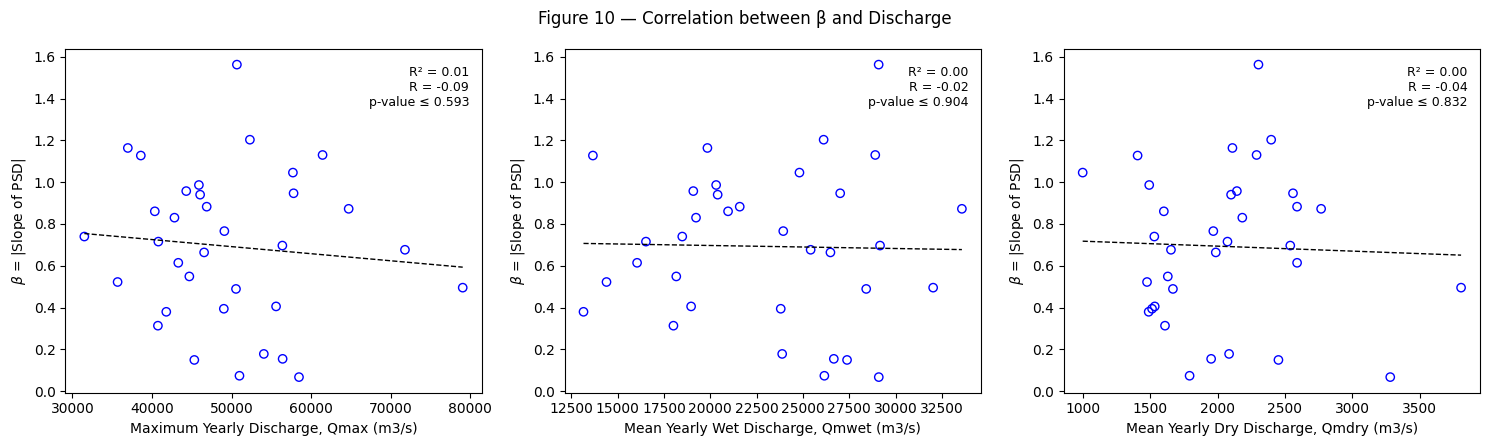

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

plot_correlation(axes[0], merged_df["Qmax"], merged_df["beta"],
                  "Maximum Yearly Discharge, Qmax (m3/s)", r"$\beta$ = |Slope of PSD|")
plot_correlation(axes[1], merged_df["Qmwet"], merged_df["beta"],
                  "Mean Yearly Wet Discharge, Qmwet (m3/s)", r"$\beta$ = |Slope of PSD|")
plot_correlation(axes[2], merged_df["Qmdry"], merged_df["beta"],
                  "Mean Yearly Dry Discharge, Qmdry (m3/s)", r"$\beta$ = |Slope of PSD|")

fig.suptitle("Figure 10 \u2014 Correlation between β and Discharge")
plt.tight_layout()
plt.show()